# Φάση Δ: Advanced Technique

Εμείς επιλέξαμε το K-Means


In [33]:
# Φάση Δ: Advanced Technique 
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml.fpm import FPGrowth
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import PCA

spark = SparkSession.builder \
    .appName("Advanced_Techniques") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

# --- 1. ASSOCIATION RULES ---
print("Εξαγωγή Κανόνων Συσχέτισης...")
df_silver = spark.read.parquet("../data/train_silver.parquet")

transactions_df = df_silver.withColumn(
    "items",
    F.array_remove(F.array(
        F.when(F.col("stroke") == 1, "Stroke").otherwise(""),
        F.when(F.col("hypertension") == 1, "Hypertension").otherwise(""),
        F.when(F.col("heart_disease") == 1, "Heart_Disease").otherwise(""),
        F.when(F.col("age") > 65, "Age_>_65").otherwise("")
    ), "")
).filter(F.size("items") > 0).select("items")

fpGrowth = FPGrowth(itemsCol="items", minSupport=0.01, minConfidence=0.1) 
rules = fpGrowth.fit(transactions_df).associationRules

print("Κανόνες Κινδύνου για Εγκεφαλικό:")
rules.filter(F.array_contains(F.col("consequent"), "Stroke")).sort(F.col("lift").desc()).show(truncate=False)

# --- 2. CLUSTERING (K-MEANS) ---
print("Εκτέλεση K-Means...")
train_gold = spark.read.parquet("../data/train_gold.parquet")
kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=2, seed=22390225)
#kmeans = KMeans(featuresCol="features", predictionCol="cluster", seed=22390225)

kmeans_preds = kmeans.fit(train_gold).transform(train_gold)

pca = PCA(k=2, inputCol="features", outputCol="pca_features")
kmeans_pca = pca.fit(kmeans_preds).transform(kmeans_preds)

kmeans_pca.select("stroke", "cluster", "pca_features").write.mode("overwrite").parquet("../data/preds_kmeans.parquet")
#spark.stop()

26/06/07 14:48:33 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Εξαγωγή Κανόνων Συσχέτισης...
Κανόνες Κινδύνου για Εγκεφαλικό:
+-------------------------+----------+-------------------+------------------+--------------------+
|antecedent               |consequent|confidence         |lift              |support             |
+-------------------------+----------+-------------------+------------------+--------------------+
|[Hypertension, Age_>_65] |[Stroke]  |0.23076923076923078|1.2396878483835005|0.03776978417266187 |
|[Heart_Disease, Age_>_65]|[Stroke]  |0.21014492753623187|1.128894489953091 |0.026079136690647483|
|[Heart_Disease]          |[Stroke]  |0.18018018018018017|0.9679244461853157|0.03597122302158273 |
|[Age_>_65]               |[Stroke]  |0.1671018276762402 |0.8976677892559377|0.11510791366906475 |
|[Hypertension]           |[Stroke]  |0.14039408866995073|0.7541943314057257|0.051258992805755396|
+-------------------------+----------+-------------------+------------------+--------------------+

Εκτέλεση K-Means...


Εύρεση βέλτιστου K με την Elbow Method...
Για K = 2, το Training Cost (WSSSE) είναι: 143070.51
Για K = 3, το Training Cost (WSSSE) είναι: 130855.85
Για K = 4, το Training Cost (WSSSE) είναι: 123369.98
Για K = 5, το Training Cost (WSSSE) είναι: 118505.81
Για K = 6, το Training Cost (WSSSE) είναι: 112539.68
Για K = 7, το Training Cost (WSSSE) είναι: 105731.45
Για K = 8, το Training Cost (WSSSE) είναι: 102912.18


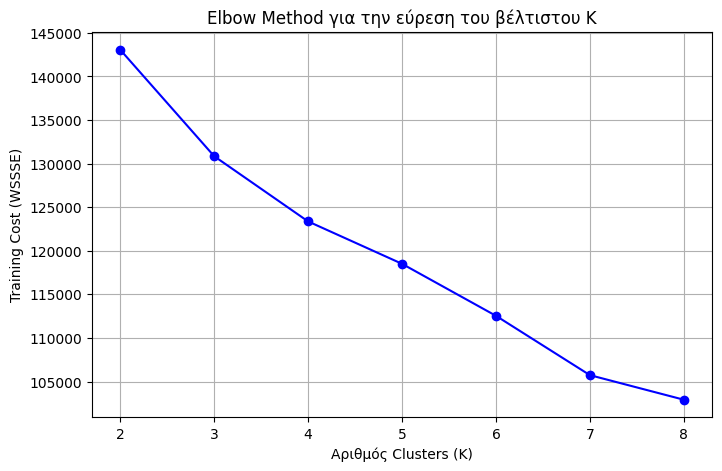

In [34]:
# K Means μέσω Elbow Method
# Kmeans μέσω elbow method
import matplotlib.pyplot as plt
import pandas as pd

print("Εύρεση βέλτιστου K με την Elbow Method...")

# Διαβάζουμε τα χρυσά δεδομένα (αν δεν είναι ήδη φορτωμένα)
train_gold = spark.read.parquet("../data/train_gold.parquet")

# Λίστα για την αποθήκευση του κόστους (Within Set Sum of Squared Errors)
costs = []
k_range = range(2, 9)  # Δοκιμάζουμε k από 2 έως 8

for k_val in k_range:
    # Εκπαίδευση του μοντέλου για το τρέχον k
    km = KMeans(featuresCol="features", k=k_val, seed=42)
    model = km.fit(train_gold)
    
    # Στο PySpark, το trainingCost μας δίνει το WSSSE
    cost = model.summary.trainingCost
    costs.append(cost)
    print(f"Για K = {k_val}, το Training Cost (WSSSE) είναι: {cost:.2f}")

# Δημιουργία γραφήματος για την οπτικοποίηση του "αγκώνα"
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), costs, marker='o', linestyle='-', color='b')
plt.xlabel('Αριθμός Clusters (K)')
plt.ylabel('Training Cost (WSSSE)')
plt.title('Elbow Method για την εύρεση του βέλτιστου K')
plt.grid(True)
plt.show()

# --- Σημείωση: Αφού δεις το γράφημα, επιλέγεις το K εκεί που "σπάει" η καμπύλη ---

Εύρεση βέλτιστου K με το Silhouette Score...
Για K = 2, το Silhouette Score είναι: 0.3502
Για K = 3, το Silhouette Score είναι: 0.1905
Για K = 4, το Silhouette Score είναι: 0.1921
Για K = 5, το Silhouette Score είναι: 0.1996
Για K = 6, το Silhouette Score είναι: 0.1949
Για K = 7, το Silhouette Score είναι: 0.2095
Για K = 8, το Silhouette Score είναι: 0.2136


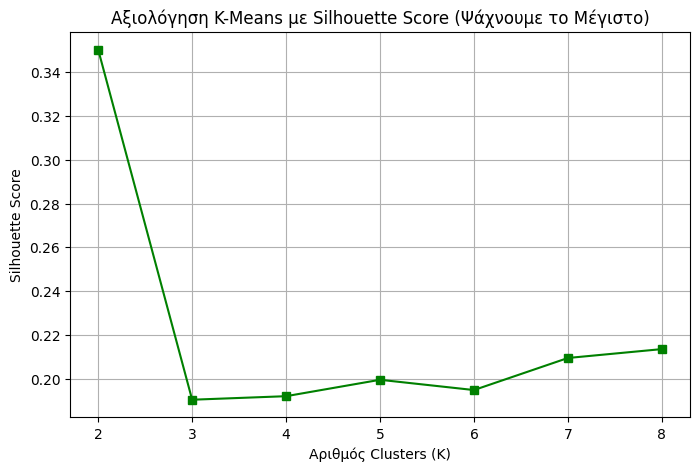

In [35]:
# K Means μέσω Silhouette Score
# K Means μέσω Silhouette Score
import matplotlib.pyplot as plt
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("Εύρεση βέλτιστου K με το Silhouette Score...")

# Υποθέτουμε ότι το train_gold υπάρχει ήδη (π.χ. train_gold = spark.read.parquet("../data/train_gold.parquet"))

silhouette_scores = []
k_range = range(2, 9)  # Δοκιμάζουμε K από 2 έως 8

# Ορίζουμε τον Αξιολογητή (Evaluator)
# Σημείωση: Χρησιμοποιούμε predictionCol="cluster" όπως το είχες ορίσει αρχικά
evaluator = ClusteringEvaluator(predictionCol="cluster", featuresCol="features", metricName="silhouette")

for k_val in k_range:
    # 1. Ορισμός και εκπαίδευση του μοντέλου
    km = KMeans(featuresCol="features", predictionCol="cluster", k=k_val, seed=42)
    model = km.fit(train_gold)
    
    # 2. Παραγωγή προβλέψεων (τα assignments στα clusters)
    predictions = model.transform(train_gold)
    
    # 3. Υπολογισμός του Silhouette Score
    score = evaluator.evaluate(predictions)
    silhouette_scores.append(score)
    print(f"Για K = {k_val}, το Silhouette Score είναι: {score:.4f}")

# Δημιουργία γραφήματος για την οπτικοποίηση των σκορ
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker='s', linestyle='-', color='g')
plt.xlabel('Αριθμός Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Αξιολόγηση K-Means με Silhouette Score (Ψάχνουμε το Μέγιστο)')
plt.grid(True)
plt.show()

# --- Σημείωση: Επίλεξε το K που αντιστοιχεί στο υψηλότερο σημείο του γραφήματος ---

Προετοιμασία δεδομένων για το Plot των K-Means Clusters...


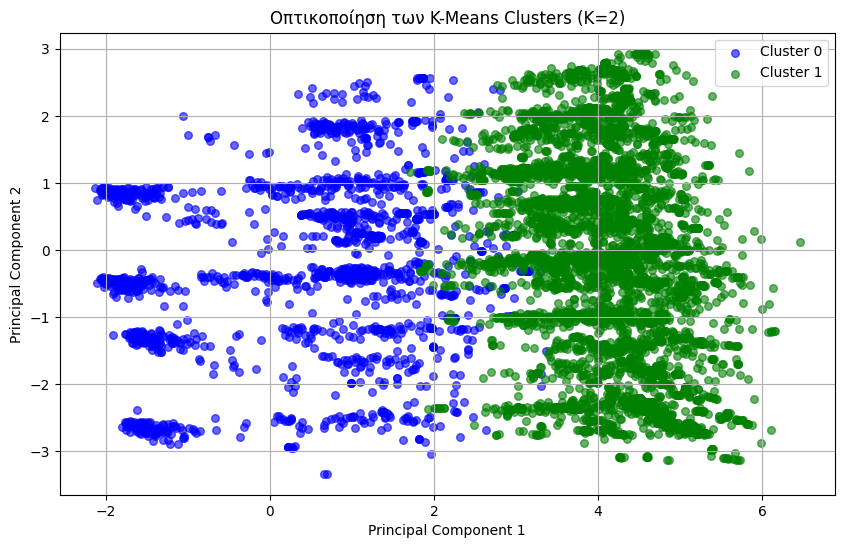

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

print("Προετοιμασία δεδομένων για το Plot των K-Means Clusters...")
# Προσοχή: Εδώ επιλέγουμε τη στήλη 'cluster', ΟΧΙ το 'stroke'
plot_df = kmeans_pca.select("pca_features", "cluster").toPandas()

# Εξαγωγή των PC1 και PC2
plot_df['PC1'] = plot_df['pca_features'].apply(lambda vec: float(vec[0]))
plot_df['PC2'] = plot_df['pca_features'].apply(lambda vec: float(vec[1]))

plt.figure(figsize=(10, 6))

# Ορίζουμε 3 χρώματα για τα 3 clusters (0, 1, 2)
colors = {0: 'blue', 1: 'green', 2: 'red'}

# Φτιάχνουμε τα σημεία για κάθε cluster
for cluster_id in sorted(plot_df['cluster'].unique()):
    cluster_data = plot_df[plot_df['cluster'] == cluster_id]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], 
                alpha=0.6, label=f'Cluster {cluster_id}', 
                color=colors.get(cluster_id, 'black'), s=30)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Οπτικοποίηση των K-Means Clusters (K={kmeans.getK()})')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
import pandas as pd
import numpy as np
import pyspark.sql.functions as F

# 1. Φόρτωση των DataFrames (Silver & Gold)
df_silver = spark.read.parquet("../data/train_silver.parquet")
train_gold = spark.read.parquet("../data/train_gold.parquet")

# 2. Εντοπισμός των κατηγορικών στηλών (π.χ. όσες καταλήγουν σε _index)
cat_cols = [field.name for field in df_silver.schema.fields if field.name.endswith("_index")]

# 3. Dynamic Mapping: Διαβάζουμε από το Silver τις πραγματικές String τιμές 
# με τη σειρά συχνότητας που χρησιμοποιεί το StringIndexer του Spark
human_categorical_names = []

for col in cat_cols:
    # Βρίσκουμε το αρχικό όνομα της στήλης (π.χ. από 'work_type_index' -> 'work_type')
    original_col_name = col.replace("_index", "")
    
    # Αν στο Silver έχεις κρατήσει τις αρχικές string στήλες, τις διαβάζουμε με βάση τη συχνότητα του index.
    # Αν οι string στήλες έχουν διαγραφεί, μπορείς να αντικαταστήσεις το original_col_name με το σωστό όνομα.
    try:
        distinct_vals = df_silver.groupBy(original_col_name, col) \
                                 .count() \
                                 .sort(F.asc(col)) \
                                 .toPandas()[original_col_name].tolist()
        
        # Το Spark OneHotEncoder (dropLast=True) πετάει ΠΑΝΤΑ την τελευταία τιμή (n-1)
        kept_vals = distinct_vals[:-1]
        
        for val in kept_vals:
            human_categorical_names.append(f"{original_col_name}_{val}")
            
    except Exception:
        # Αν οι αρχικές string στήλες δεν υπάρχουν στο Silver, φτιάχνουμε ένα καθαρό index label
        unique_indices = df_silver.select(col).distinct().sort(col).toPandas()[col].tolist()
        for idx in unique_indices[:-1]:
            human_categorical_names.append(f"{original_col_name}_Value_{int(idx)}")

num_cat_features = len(human_categorical_names)

# 4. Μετατροπή των predictions του K-Means σε Pandas Matrix
pdf_gold = kmeans_preds.select("features", "cluster").toPandas()
features_matrix = np.vstack(pdf_gold['features'].apply(lambda x: x.toArray()))

# 5. Απομονώνουμε ΜΟΝΟ το categorical κομμάτι του vector (0 έως num_cat_features)
cat_features_matrix = features_matrix[:, 0:num_cat_features]
cat_features_binary = (cat_features_matrix > 0.001).astype(int)

# 6. Δημιουργία του DataFrame με τα ΑΝΘΡΩΠΙΝΑ ονόματα
pdf_cat_human = pd.DataFrame(cat_features_binary, columns=human_categorical_names)
pdf_cat_human['cluster'] = pdf_gold['cluster']

# 7. Τελικό Report Ποσοστών
print("\n" + "="*80)
print("=== ΑΝΘΡΩΠΙΝΑ ΠΟΣΟΣΤΑ (%) ΚΑΤΗΓΟΡΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===")
print("="*80)
cat_profile_human = pdf_cat_human.groupby('cluster').mean() * 100
print(cat_profile_human.round(1).T.to_string())


=== ΑΝΘΡΩΠΙΝΑ ΠΟΣΟΣΤΑ (%) ΚΑΤΗΓΟΡΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===
cluster                             0     1
gender_Female                    61.1  54.7
gender_Male                      38.8  45.3
ever_married_Yes                  0.1   0.0
work_type_Private                 0.0  99.9
work_type_Self-employed         100.0   0.1
work_type_children               46.9  60.0
work_type_Govt_job               10.4  25.5
Residence_type_Urban             34.1   4.5
smoking_status_never smoked       7.7  10.0
smoking_status_Unknown            1.0   0.0
smoking_status_formerly smoked   53.6  51.3


In [38]:
import pandas as pd

# 1. Επιλέγουμε μόνο το cluster και το stroke από τις προβλέψεις
pdf_stroke_test = kmeans_preds.select("cluster", "stroke").toPandas()

# 2. Υπολογίζουμε το ποσοστό (%) εμφάνισης stroke ανά cluster
print("=" * 50)
print("TEST: ΠΟΣΟΣΤΟ (%) STROKE ANA CLUSTER")
print("=" * 50)

# Το mean() σε binary στήλη (0/1) πολλαπλασιαζόμενο επί 100 μας δίνει το ποσοστό %
stroke_profile = pdf_stroke_test.groupby("cluster").mean() * 100
print(stroke_profile.round(1).to_string())

TEST: ΠΟΣΟΣΤΟ (%) STROKE ANA CLUSTER
         stroke
cluster        
0          23.6
1          58.2


In [39]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE

# 1. Φόρτωση του Silver DataFrame από το Parquet του Engineer
df_silver = spark.read.parquet("../data/train_silver.parquet")

# Μετατροπή σε Pandas για να καθαρίσουμε τις String στήλες που βρωμίζουν το SMOTE
pdf_silver_raw = df_silver.toPandas()

# ==========================================
# ΑΥΤΟΜΑΤΟΣ ΔΙΑΧΩΡΙΣΜΟΣ ΜΕ ΒΑΣΗ ΤΟ PANDAS
# ==========================================
# Απομονώνουμε μόνο τις στήλες που είναι πραγματικά αριθμητικές (float/int) στο Pandas
# Έτσι πετάμε αυτόματα τις string στήλες όπως 'gender', 'work_type' που έχουν τα text labels
numeric_and_indexed_df = pdf_silver_raw.select_dtypes(include=[np.number])

# Από αυτές, οι αριθμητικές (continuous) είναι όσες ΔΕΝ είναι το target 'stroke' και ΔΕΝ είναι indexes
numeric_cols = [c for c in numeric_and_indexed_df.columns if c != "stroke" and not c.endswith("_index")]

# Οι κατηγορικοί indexes είναι όσες στήλες τελειώνουν σε _index
cat_cols = [c for c in numeric_and_indexed_df.columns if c.endswith("_index")]

print(f"Dynamic continuous αριθμητικές στήλες: {numeric_cols}")
print(f"Dynamic κατηγορικοί indexes για το SMOTE: {cat_cols}")

# 2. Ασφαλές SMOTE μόνο με τις αριθμητικές στήλες (δεν θα ξαναδεί ποτέ 'Female')
X_res, y_res = SMOTE(random_state=42).fit_resample(numeric_and_indexed_df[numeric_cols + cat_cols], numeric_and_indexed_df["stroke"])
stds = X_res[numeric_cols].std(ddof=1)

# 3. Εξαγωγή των scaled αριθμητικών χαρακτηριστικών από το Gold Vector
pdf_gold = kmeans_preds.select("features", "cluster").toPandas()
features_matrix = np.vstack(pdf_gold['features'].apply(lambda x: x.toArray()))

# Οι κατηγορικές προηγούνται στο vector, βρίσκουμε dynamic πού ξεκινούν οι αριθμητικές
num_cat_features = features_matrix.shape[1] - len(numeric_cols)
numeric_features_scaled = features_matrix[:, num_cat_features:]

# 4. Δημιουργία DataFrame με τις ΠΡΑΓΜΑΤΙΚΕΣ (Unscaled) τιμές
pdf_numeric_unscaled = pd.DataFrame(columns=numeric_cols)
for i, col in enumerate(numeric_cols):
    pdf_numeric_unscaled[col] = numeric_features_scaled[:, i] * stds[col]

# Προσθήκη της στήλης του cluster
pdf_numeric_unscaled['cluster'] = pdf_gold['cluster']

# 5. Υπολογισμός Standard Στατιστικών (Mean, Min, Max, Std) ανά Cluster
print("\n" + "="*90)
print("=== ΣΤΑΤΙΣΤΙΚΟ ΠΡΟΦΙΛ ΠΡΑΓΜΑΤΙΚΩΝ ΑΡΙΘΜΗΤΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===")
print("="*90)

for cluster_id in sorted(pdf_numeric_unscaled['cluster'].unique()):
    print(f"\n--- CLUSTER {cluster_id} ---")
    cluster_data = pdf_numeric_unscaled[pdf_numeric_unscaled['cluster'] == cluster_id][numeric_cols]
    summary = cluster_data.describe().loc[['mean', 'min', 'max', 'std']]
    print(summary.round(2).to_string())

Dynamic continuous αριθμητικές στήλες: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Dynamic κατηγορικοί indexes για το SMOTE: ['gender_index', 'ever_married_index', 'work_type_index', 'Residence_type_index', 'smoking_status_index']

=== ΣΤΑΤΙΣΤΙΚΟ ΠΡΟΦΙΛ ΠΡΑΓΜΑΤΙΚΩΝ ΑΡΙΘΜΗΤΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===

--- CLUSTER 0 ---
        age  hypertension  heart_disease  avg_glucose_level    bmi
mean  32.08          0.04           0.03              99.56  26.14
min    0.08          0.00           0.00              55.12  10.30
max   82.00          1.00           1.00             256.74  97.60
std   26.13          0.19           0.16              37.61   7.43

--- CLUSTER 1 ---
        age  hypertension  heart_disease  avg_glucose_level    bmi
mean  62.09          0.10           0.06             122.78  30.05
min   18.00          0.00           0.00              55.22  11.50
max   82.00          1.00           1.00             267.76  92.00
std   15.09          0.3